In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/final_dataset"


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))


In [ ]:
train_dir = BASE_DIR + "/train"
val_dir   = BASE_DIR + "/val"
test_dir  = BASE_DIR + "/test"


In [ ]:
import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True
)

print(type(train_ds))


Found 25686 files belonging to 47 classes.
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [ ]:
for images, labels in train_ds.take(1):
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())


Min pixel value: 0.0
Max pixel value: 255.0


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)


Found 25686 files belonging to 47 classes.
Found 5488 files belonging to 47 classes.
Found 5551 files belonging to 47 classes.


In [ ]:
for images, labels in train_ds.take(1):
    print("After preprocess - Min:", images.numpy().min())
    print("After preprocess - Max:", images.numpy().max())


After preprocess - Min: -123.68
After preprocess - Max: 151.061


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)


(32, 224, 224, 3)


In [ ]:
NUM_CLASSES = train_ds.element_spec[1].shape[1]
print("Number of classes:", NUM_CLASSES)


Number of classes: 47


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet50 layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,124,335 (92.03 MB)

 Trainable params: 536,623 (2.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 5597s 7s/step - accuracy: 0.4123 - loss: 2.4843 - val_accuracy: 0.8065 - val_loss: 0.8700
Epoch 2/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 160s 199ms/step - accuracy: 0.7650 - loss: 0.9590 - val_accuracy: 0.8810 - val_loss: 0.5117
Epoch 3/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 158s 197ms/step - accuracy: 0.8427 - loss: 0.6223 - val_accuracy: 0.9073 - val_loss: 0.3624
Epoch 4/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 157s 195ms/step - accuracy: 0.8822 - loss: 0.4627 - val_accuracy: 0.9227 - val_loss: 0.2750
Epoch 5/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 173s 215ms/step - accuracy: 0.9071 - loss: 0.3577 - val_accuracy: 0.9426 - val_loss: 0.2172
Epoch 6/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 158s 197ms/step - accuracy: 0.9224 - loss: 0.2965 - val_accuracy: 0.9530 - val_loss: 0.1791
Epoch 7/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 202s 197ms/step - accuracy: 0.9361 - loss: 0.2491 - val_accuracy: 0.9597 - val_loss: 0.1493
Epoch 8/15
803/803 ━━━━━━━━━━━━━━━━━━━━ 159s 198ms/step - accuracy: 0.9471 - l

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc * 100, "%")


174/174 ━━━━━━━━━━━━━━━━━━━━ 1012s 6s/step - accuracy: 0.9982 - loss: 0.0179
Test Accuracy: 99.08124804496765 %


In [ ]:
model.save("/content/drive/MyDrive/BHM_resnet50_mudra_model.h5")


In [ ]:
model.save("/content/drive/MyDrive/BHM_resnet50_mudra_model.keras")


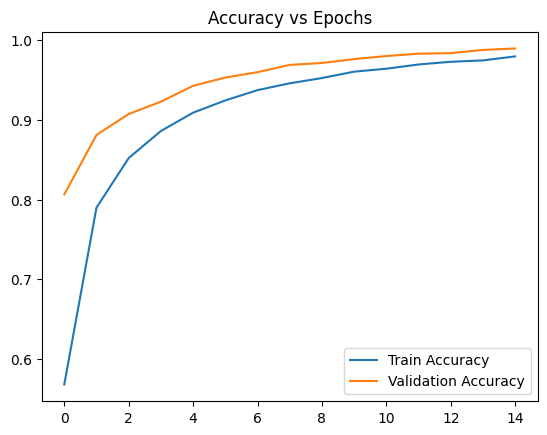

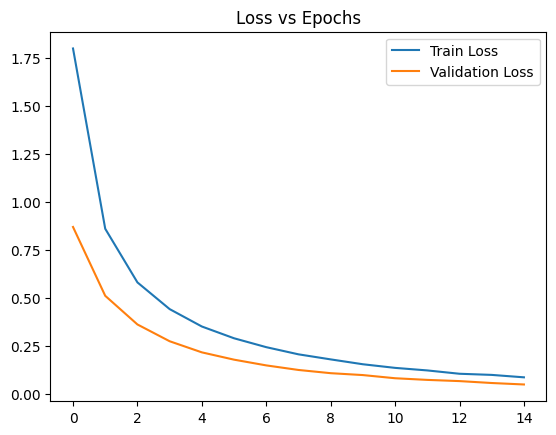

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()


174/174 ━━━━━━━━━━━━━━━━━━━━ 37s 189ms/step


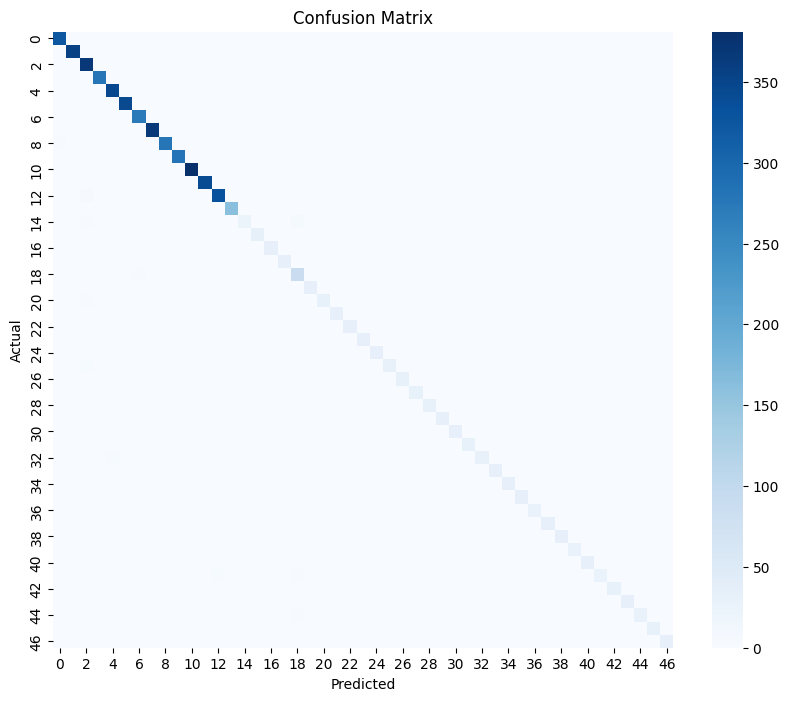

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = np.concatenate([y.numpy().argmax(axis=1) for x, y in test_ds])
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import numpy as np

# True labels
y_true = np.concatenate([
    y.numpy().argmax(axis=1) for _, y in test_ds
])

# Predicted labels
y_pred = np.argmax(model.predict(test_ds), axis=1)


174/174 ━━━━━━━━━━━━━━━━━━━━ 29s 167ms/step


In [ ]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,          # or test_dir (both are fine)
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 25686 files belonging to 47 classes.


In [ ]:
class_names = temp_ds.class_names
print(class_names)


['Alapadmam(1)', 'Anjali(1)', 'Aralam(1)', 'Ardhachandran(1)', 'Ardhapathaka(1)', 'Berunda(1)', 'Bramaram(1)', 'Chakra(1)', 'Chandrakala(1)', 'Chaturam(1)', 'Garuda(1)', 'Hamsapaksha(1)', 'Hamsasyam(1)', 'Kangulam(1)', 'Kapith(1)', 'Kapotham(1)', 'Karkatta(1)', 'Kartariswastika(1)', 'Katakamukha', 'Katakavardhana(1)', 'Katrimukha(1)', 'Khatva(1)', 'Kilaka(1)', 'Kurma(1)', 'Matsya(1)', 'Mayura(1)', 'Mrigasirsha(1)', 'Mukulam(1)', 'Mushti(1)', 'Nagabandha(1)', 'Padmakosha(1)', 'Pasha(1)', 'Pathaka(1)', 'Pushpaputa(1)', 'Sakata(1)', 'Samputa(1)', 'Sarpasirsha(1)', 'Shanka(1)', 'Shivalinga(1)', 'Shukatundam(1)', 'Sikharam(1)', 'Simhamukham(1)', 'Suchi(1)', 'Swastikam(1)', 'Tamarachudam(1)', 'Trishulam(1)', 'Varaha(1)']


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)


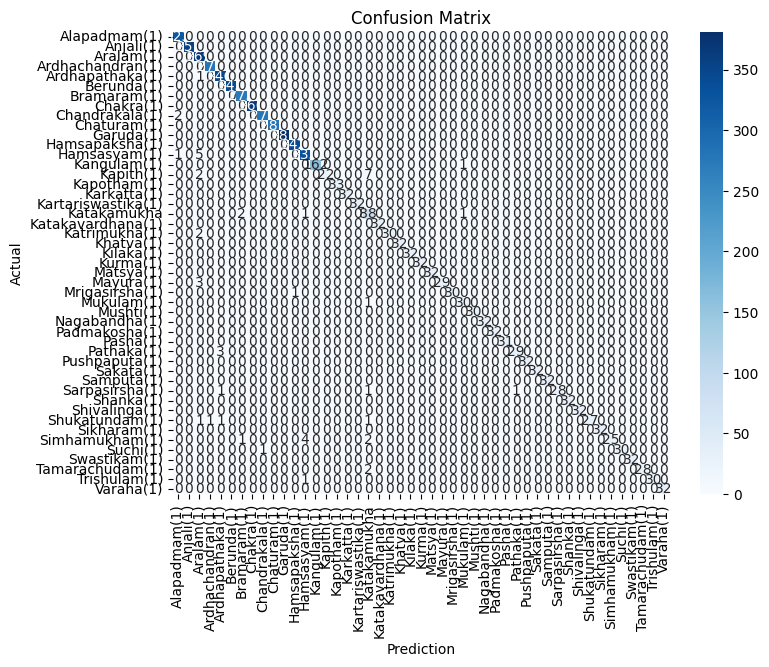

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,          # numbers inside boxes
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [ ]:
target_class = 0   # change index as needed
print("Target class:", class_names[target_class])


Target class: Alapadmam(1)


In [ ]:
import numpy as np

# True labels (binary)
y_true_binary = (y_true == target_class).astype(int)

# Predicted labels (binary)
y_pred_binary = (y_pred == target_class).astype(int)


In [ ]:
from sklearn.metrics import confusion_matrix

cm_binary = confusion_matrix(y_true_binary, y_pred_binary)
print(cm_binary)


[[5225    3]
 [   0  323]]


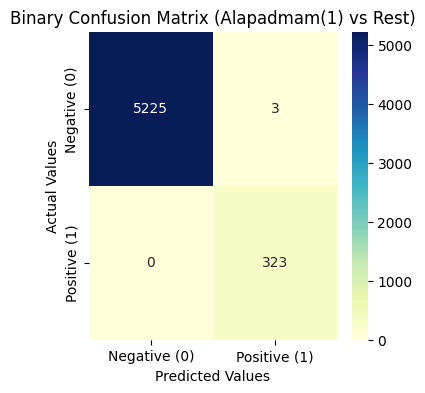

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,4))
sns.heatmap(
    cm_binary,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["Negative (0)", "Positive (1)"],
    yticklabels=["Negative (0)", "Positive (1)"]
)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title(f"Binary Confusion Matrix ({class_names[target_class]} vs Rest)")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                    precision    recall  f1-score   support

      Alapadmam(1)       0.99      1.00      1.00       323
         Anjali(1)       1.00      1.00      1.00       357
         Aralam(1)       0.96      1.00      0.98       369
  Ardhachandran(1)       1.00      1.00      1.00       279
   Ardhapathaka(1)       0.99      1.00      0.99       347
        Berunda(1)       1.00      1.00      1.00       345
       Bramaram(1)       0.99      1.00      0.99       273
         Chakra(1)       1.00      1.00      1.00       366
    Chandrakala(1)       1.00      0.99      0.99       281
       Chaturam(1)       1.00      1.00      1.00       281
         Garuda(1)       1.00      1.00      1.00       381
    Hamsapaksha(1)       1.00      1.00      1.00       342
      Hamsasyam(1)       0.98      0.98      0.98       339
       Kangulam(1)       1.00      0.99      1.00       163
         Kapith(1)       1.00      0.71      0.83        31
       Kapotham(1)       1.00      1.00

In [ ]:
def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img("/content/drive/MyDrive/mudra1.jpg", target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    pred = model.predict(img)
    return class_names[np.argmax(pred)]


In [ ]:
result = predict_image("/content/drive/MyDrive/mudra2.jpg")
print("Predicted Mudra:", result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted Mudra: Chakra(1)


In [ ]:
result = predict_image("/content/drive/MyDrive/mudra2.jpg")
print("Predicted Mudra:", result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Mudra: Chakra(1)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(224, 224)
    )
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    pred = model.predict(img)
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    return predicted_class, confidence

# ---- Call the function ----
img_path = "/content/drive/MyDrive/mudra3.jpg"

label, conf = predict_image(img_path)
print(f"Predicted Mudra: {label}")
print(f"Confidence: {conf:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Mudra: Katakamukha
Confidence: 80.14%


In [ ]:
import tensorflow as tf

rebuild_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/final_dataset/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False   # IMPORTANT
)

correct_class_names = rebuild_ds.class_names
print(len(correct_class_names))
print(correct_class_names[:10])


Found 25686 files belonging to 47 classes.
47
['Alapadmam(1)', 'Anjali(1)', 'Aralam(1)', 'Ardhachandran(1)', 'Ardhapathaka(1)', 'Berunda(1)', 'Bramaram(1)', 'Chakra(1)', 'Chandrakala(1)', 'Chaturam(1)']


In [ ]:
class_names = correct_class_names


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)

    print(f"Debug: Before preprocess_input - Shape: {img.shape}, Min: {img.min():.2f}, Max: {img.max():.2f}")

    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    print(f"Debug: After preprocess_input - Shape: {img.shape}, Min: {img.min():.2f}, Max: {img.max():.2f}")

    preds = model.predict(img)
    idx = np.argmax(preds)
    confidence = preds[0][idx] * 100

    return class_names[idx], confidence

img_path = "/content/drive/MyDrive/final_dataset/test/Berunda(1)/Berunda(1)_Berunda  _1_b1.jpg"
label, conf = predict_image(img_path)
print("Predicted Mudra:", label)
print(f"Confidence: {conf:.2f}%")

Debug: Before preprocess_input - Shape: (224, 224, 3), Min: 0.00, Max: 245.00
Debug: After preprocess_input - Shape: (1, 224, 224, 3), Min: -123.68, Max: 121.32
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Mudra: Berunda(1)
Confidence: 100.00%


In [ ]:
import mediapipe as mp

try:
    _ = mp.solutions.hands
    print("mediapipe.solutions.hands is accessible.")
except AttributeError:
    print("Error: mediapipe.solutions.hands is NOT accessible. This might require a runtime restart or re-installation.")
    print("Please go to `Runtime` -> `Restart runtime` from the Colab menu and then re-run the `!pip install mediapipe` cell and subsequent cells.")

Error: mediapipe.solutions.hands is NOT accessible. This might require a runtime restart or re-installation.
Please go to `Runtime` -> `Restart runtime` from the Colab menu and then re-run the `!pip install mediapipe` cell and subsequent cells.


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input


In [ ]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)

def crop_hand(img_path):
    image = cv2.imread(img_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)

    if not results.multi_hand_landmarks:
        return None

    h, w, _ = image.shape
    hand_landmarks = results.multi_hand_landmarks[0]

    xs = [int(lm.x * w) for lm in hand_landmarks.landmark]
    ys = [int(lm.y * h) for lm in hand_landmarks.landmark]

    x_min, x_max = max(min(xs)-20, 0), min(max(xs)+20, w)
    y_min, y_max = max(min(ys)-20, 0), min(max(ys)+20, h)

    cropped = image[y_min:y_max, x_min:x_max]
    return cropped


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import mediapipe as mp
import cv2

print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)


MediaPipe version: 0.10.32
OpenCV version: 4.12.0


In [ ]:
import mediapipe as mp
import cv2
import numpy as np

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)


AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/BHM_resnet50_mudra_model.keras")
print("Model loaded successfully")


Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import tensorflow as tf

rebuild_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/final_dataset/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

class_names = rebuild_ds.class_names
print("Classes:", len(class_names))


Found 25686 files belonging to 47 classes.
Classes: 47


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_external_image_safe(img_path, threshold=50):
    image = cv2.imread(img_path)
    if image is None:
        return "Invalid image", 0.0

    h, w, _ = image.shape
    image = image[int(h*0.2):int(h*0.8), int(w*0.2):int(w*0.8)]

    image = cv2.resize(image, (224,224))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    preds = model.predict(image)
    idx = np.argmax(preds)
    conf = preds[0][idx] * 100

    if conf < threshold:
        return "Uncertain prediction (external image)", conf

    return class_names[idx], conf


In [ ]:
label, conf = predict_external_image_safe("/content/drive/MyDrive/mudra1.jpg")
print("Prediction:", label)
print(f"Confidence: {conf:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Prediction: Uncertain prediction (external image)
Confidence: 38.43%


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Load the image and resize to 224x224 (ResNet standard)
img = image.load_img("/content/drive/MyDrive/mudra1.jpg", target_size=(224, 224))

# 2. Convert to a numpy array
x = image.img_to_array(img)

# 3. Add a fourth dimension (batch size) because model.predict expects (1, 224, 224, 3)
x = np.expand_dims(x, axis=0)

# 4. Apply ResNet50 specific preprocessing (Scaling/Mean Subtraction)
x = preprocess_input(x)

# 5. Get the prediction
preds = model.predict(x)

# 6. Interpret the results
print(np.argmax(preds)) # This gives you the predicted class index

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
7


In [ ]:
print(f"The model predicted index {np.argmax(preds)}, which is: {class_names[np.argmax(preds)]}")

The model predicted index 7, which is: Chakra(1)


In [ ]:
img_path = "/content/drive/MyDrive/final_dataset/test/Berunda(1)/Berunda(1)_Berunda  _1_b1.jpg"

import os
print(os.path.exists(img_path))


True


In [ ]:
import os

folder = "/content/drive/MyDrive/final_dataset/test/Berunda(1)"
print(os.listdir(folder))


['Berunda(1)_Berunda  _281_b1.jpg', 'Berunda(1)_Berunda  _325_b0.jpg', 'Berunda(1)_Berunda  _140_b1.jpg', 'Berunda(1)_Berunda  _238.jpg', 'Berunda(1)_Berunda  _341.jpg', 'Berunda(1)_Berunda  _228_b0.jpg', 'Berunda(1)_Berunda  _178_h.jpg', 'Berunda(1)_Berunda  _235_h.jpg', 'Berunda(1)_Berunda  _321_b0.jpg', 'Berunda(1)_Berunda  _487_h.jpg', 'Berunda(1)_Berunda  _207_h.jpg', 'Berunda(1)_Berunda  _517.jpg', 'Berunda(1)_Berunda  _498_b1.jpg', 'Berunda(1)_Berunda  _386_h.jpg', 'Berunda(1)_Berunda  _247_b0.jpg', 'Berunda(1)_Berunda  _505.jpg', 'Berunda(1)_Berunda  _358_b1.jpg', 'Berunda(1)_Berunda  _145_b0.jpg', 'Berunda(1)_Berunda  _14_h.jpg', 'Berunda(1)_Berunda  _76.jpg', 'Berunda(1)_Berunda  _493_b0.jpg', 'Berunda(1)_Berunda  _375_b1.jpg', 'Berunda(1)_Berunda  _374_b1.jpg', 'Berunda(1)_Berunda  _508_b1.jpg', 'Berunda(1)_Berunda  _406.jpg', 'Berunda(1)_Berunda  _326_h.jpg', 'Berunda(1)_Berunda  _256_b1.jpg', 'Berunda(1)_Berunda  _519_b0.jpg', 'Berunda(1)_Berunda  _535_h.jpg', 'Berunda(1)_

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)  # VERY IMPORTANT

    predictions = model.predict(img_array)
    class_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    return class_names[class_index], confidence


In [ ]:
img_path = "/content/drive/MyDrive/mudra3.jpg"
label, confidence = predict_image(img_path)

print("Predicted Mudra:", label)
print(f"Confidence: {confidence:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Mudra: Katakamukha
Confidence: 80.14%


In [ ]:
model.save("/content/drive/MyDrive/final_mudra_model_final.h5")


In [ ]:
def predict_image_top3(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)[0]
    top3 = np.argsort(preds)[-3:][::-1]

    for i in top3:
        print(class_names[i], ":", f"{preds[i]*100:.2f}%")


In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np


In [ ]:
img_path = "/content/drive/MyDrive/mudra3.jpg"

predict_image_top3(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Katakamukha : 80.14%
Shukatundam(1) : 3.54%
Mrigasirsha(1) : 2.85%


In [ ]:
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]
print("Uploaded image:", img_path)

# Predict
label, conf = predict_image(img_path)

print("Predicted Mudra:", label)
print(f"Confidence: {conf:.2f}%")


Saving mudraimage.jpg to mudraimage.jpg
Uploaded image: mudraimage.jpg


NameError: name 'predict_image' is not defined

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)

    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    preds = model.predict(img)
    idx = np.argmax(preds)
    confidence = preds[0][idx] * 100

    return class_names[idx], confidence


In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

label, conf = predict_image(img_path)
print("Predicted Mudra:", label)
print(f"Confidence: {conf:.2f}%")


Saving mudraimage.jpg to mudraimage.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Mudra: Ardhapathaka(1)
Confidence: 99.59%


In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

label, conf = predict_image(img_path)
print("Predicted Mudra:", label)
print(f"Confidence: {conf:.2f}%")

Saving testimage.jpg to testimage.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Mudra: Chandrakala(1)
Confidence: 90.18%


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/final_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/final_dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)



Found 25686 files belonging to 47 classes.
Found 5488 files belonging to 47 classes.


In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=3)


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.3),
    layers.RandomTranslation(0.15, 0.15),
])


In [ ]:
import tensorflow as tf


In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(256, activation="relu")(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)


In [ ]:
NUM_CLASSES = train_ds.element_spec[1].shape[1]
print("Number of classes:", NUM_CLASSES)


Found 25686 files belonging to 47 classes.
Number of classes: 47


In [ ]:
train_dir = "/content/drive/MyDrive/final_dataset/train"
val_dir   = "/content/drive/MyDrive/final_dataset/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Found 25686 files belonging to 47 classes.
Found 5488 files belonging to 47 classes.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 5919s 7s/step - accuracy: 0.4025 - loss: 2.4134 - val_accuracy: 0.6356 - val_loss: 1.3192
Epoch 2/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 141s 175ms/step - accuracy: 0.6929 - loss: 1.1778 - val_accuracy: 0.7274 - val_loss: 0.9650
Epoch 3/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 141s 175ms/step - accuracy: 0.7629 - loss: 0.8954 - val_accuracy: 0.7699 - val_loss: 0.8017
Epoch 4/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 141s 175ms/step - accuracy: 0.7930 - loss: 0.7643 - val_accuracy: 0.8258 - val_loss: 0.6522
Epoch 5/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 139s 173ms/step - accuracy: 0.8206 - loss: 0.6589 - val_accuracy: 0.8433 - val_loss: 0.5831
Epoch 6/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 141s 176ms/step - accuracy: 0.8380 - loss: 0.5968 - val_accuracy: 0.8648 - val_loss: 0.5103
Epoch 7/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 144s 179ms/step - accuracy: 0.8436 - loss: 0.5630 - val_accuracy: 0.8712 - val_loss: 0.4797
Epoch 8/10
803/803 ━━━━━━━━━━━━━━━━━━━━ 144s 180ms/step - accuracy: 0.8526 - l

In [ ]:
model.save("/content/drive/MyDrive/BHM_resnet50_augmented.keras")
print("Augmented model saved")


Augmented model saved


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc * 100)


174/174 ━━━━━━━━━━━━━━━━━━━━ 981s 6s/step - accuracy: 0.9427 - loss: 0.2550
Test Accuracy: 89.96757864952087


In [ ]:
test_dir = "/content/drive/MyDrive/final_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)


Found 5552 files belonging to 47 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
img_path = "/content/drive/MyDrive/final_dataset/test/Ardhapathaka(1)/Ardhapathaka(1)_Ardhapathaka_0_b1.jpg"

label, conf = predict_google_image(img_path)
print("Prediction:", label)
print(f"Confidence: {conf:.2f}%")


NameError: name 'predict_google_image' is not defined

In [ ]:
class_names = train_ds.class_names
print("Number of classes:", len(class_names))
print(class_names)


Number of classes: 47
['Alapadmam(1)', 'Anjali(1)', 'Aralam(1)', 'Ardhachandran(1)', 'Ardhapathaka(1)', 'Berunda(1)', 'Bramaram(1)', 'Chakra(1)', 'Chandrakala(1)', 'Chaturam(1)', 'Garuda(1)', 'Hamsapaksha(1)', 'Hamsasyam(1)', 'Kangulam(1)', 'Kapith(1)', 'Kapotham(1)', 'Karkatta(1)', 'Kartariswastika(1)', 'Katakamukha', 'Katakavardhana(1)', 'Katrimukha(1)', 'Khatva(1)', 'Kilaka(1)', 'Kurma(1)', 'Matsya(1)', 'Mayura(1)', 'Mrigasirsha(1)', 'Mukulam(1)', 'Mushti(1)', 'Nagabandha(1)', 'Padmakosha(1)', 'Pasha(1)', 'Pathaka(1)', 'Pushpaputa(1)', 'Sakata(1)', 'Samputa(1)', 'Sarpasirsha(1)', 'Shanka(1)', 'Shivalinga(1)', 'Shukatundam(1)', 'Sikharam(1)', 'Simhamukham(1)', 'Suchi(1)', 'Swastikam(1)', 'Tamarachudam(1)', 'Trishulam(1)', 'Varaha(1)']


In [ ]:
clean_class_names = [name.replace("(1)", "").strip() for name in class_names]

print("Cleaned class names:")
print(clean_class_names)
print("Total classes:", len(clean_class_names))


Cleaned class names:
['Alapadmam', 'Anjali', 'Aralam', 'Ardhachandran', 'Ardhapathaka', 'Berunda', 'Bramaram', 'Chakra', 'Chandrakala', 'Chaturam', 'Garuda', 'Hamsapaksha', 'Hamsasyam', 'Kangulam', 'Kapith', 'Kapotham', 'Karkatta', 'Kartariswastika', 'Katakamukha', 'Katakavardhana', 'Katrimukha', 'Khatva', 'Kilaka', 'Kurma', 'Matsya', 'Mayura', 'Mrigasirsha', 'Mukulam', 'Mushti', 'Nagabandha', 'Padmakosha', 'Pasha', 'Pathaka', 'Pushpaputa', 'Sakata', 'Samputa', 'Sarpasirsha', 'Shanka', 'Shivalinga', 'Shukatundam', 'Sikharam', 'Simhamukham', 'Suchi', 'Swastikam', 'Tamarachudam', 'Trishulam', 'Varaha']
Total classes: 47


In [ ]:
save_path = "/content/drive/MyDrive/class_names_clean.txt"

with open(save_path, "w") as f:
    for name in clean_class_names:
        f.write(name + "\n")

print("Class names saved at:", save_path)


Class names saved at: /content/drive/MyDrive/class_names_clean.txt


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input


In [ ]:
def preprocess_external_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    h, w, _ = img.shape

    # center crop
    img = img[int(h*0.15):int(h*0.85), int(w*0.15):int(w*0.85)]

    img = cv2.resize(img, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return img


In [ ]:
def predict_google_image(img_path, threshold=50):
    img = preprocess_external_image(img_path)
    if img is None:
        return "Invalid Image", 0.0

    preds = model.predict(img)
    idx = np.argmax(preds)
    confidence = preds[0][idx] * 100

    if confidence < threshold:
        return "Uncertain prediction (external image)", confidence

    return class_names[idx], confidence


In [ ]:
img_path = "/content/drive/MyDrive/final_dataset/test/Ardhapathaka(1)/Ardhapathaka(1)_Ardhapathaka_0_b1.jpg"

label, conf = predict_google_image(img_path)
print("Prediction:", label)
print(f"Confidence: {conf:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: Uncertain prediction (external image)
Confidence: 33.45%


In [ ]:
img_path = "/content/drive/MyDrive/mudra1.jpg"


In [ ]:
label, conf = predict_google_image(img_path)
print("Prediction:", label)
print(f"Confidence: {conf:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prediction: Anjali(1)
Confidence: 76.90%


In [ ]:
test_dir = "/content/drive/MyDrive/final_dataset/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 5552 files belonging to 47 classes.


In [ ]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import confusion_matrix


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17

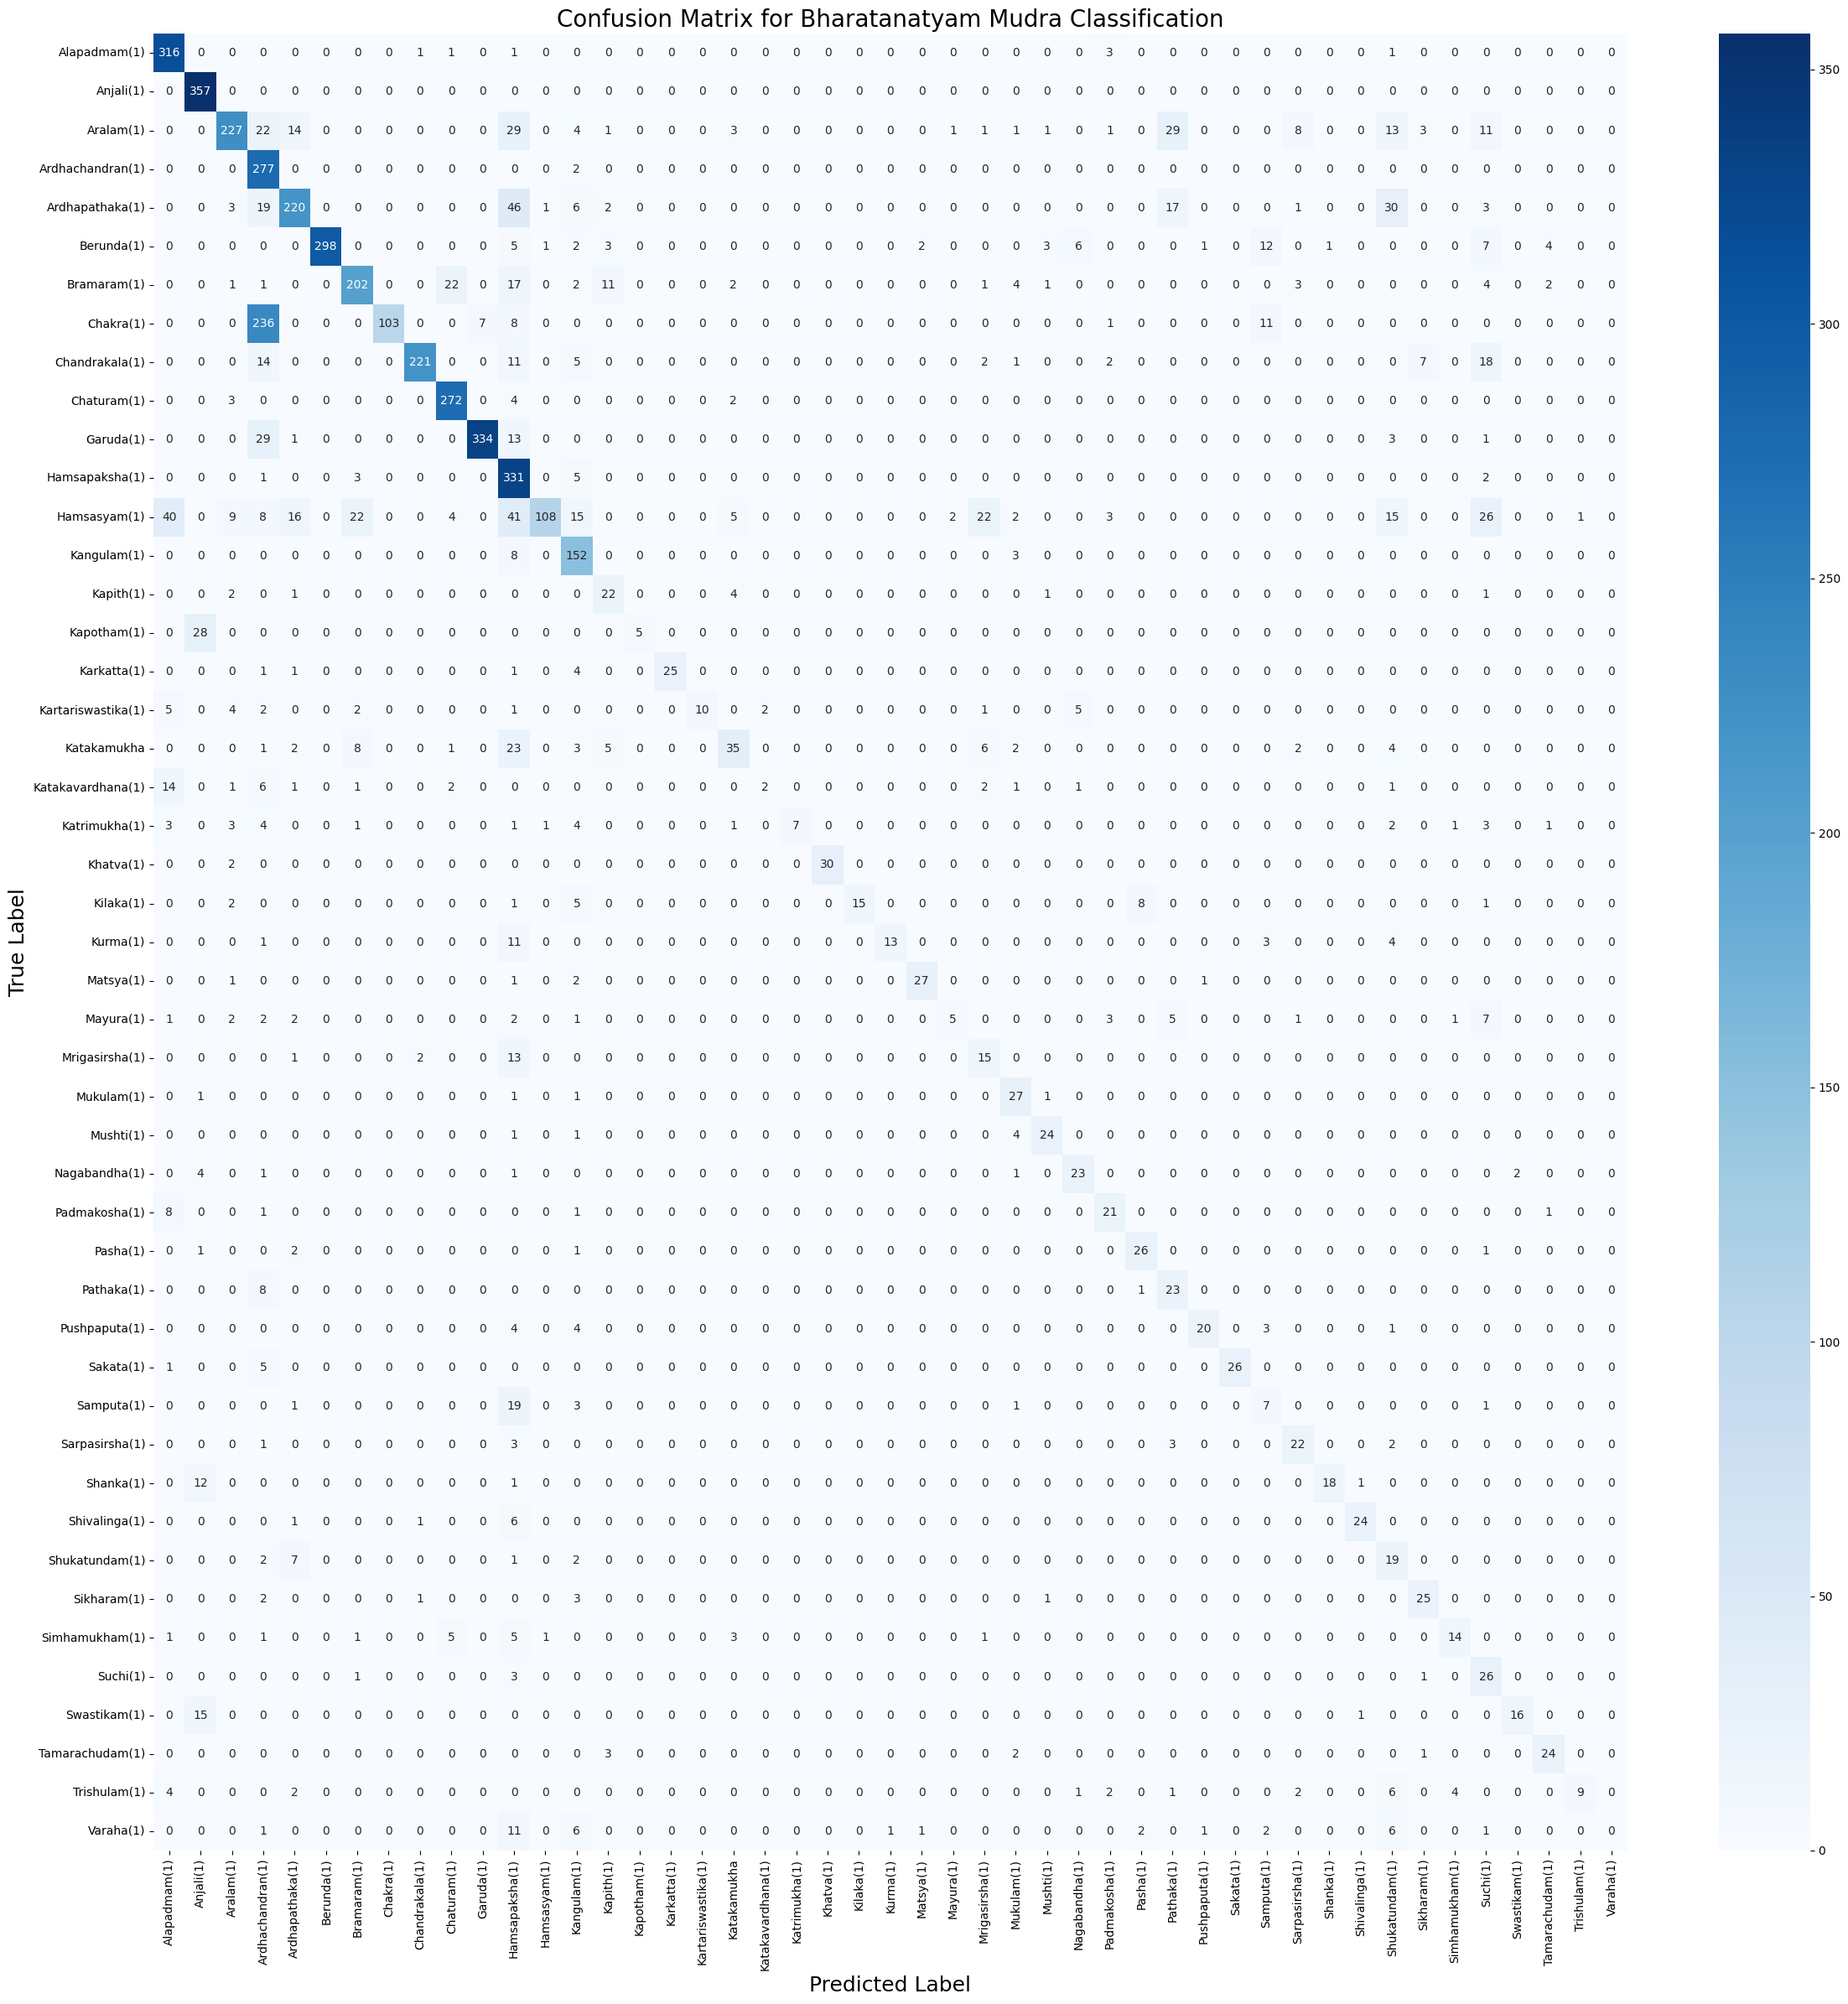

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get class names
class_names = test_ds.class_names

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24,24))
sns.heatmap(
    cm,
    annot=True,          # show numbers like your example
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix for Bharatanatyam Mudra Classification", fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_paper_style.png", dpi=300)
plt.show()
